# Phase 5 — Decision value: does it help you pick a *captain*?

**Driving question (the only one that matters):** not 'is the model accurate' but 'does it lead to a
better captaincy decision than baselines — with honest error bars?'

**What this stage tests:** template / season-average / model-mean / model x P(play) / ceiling, each
picking one captain per GW, scored by realized points (blanks=0). Reads: mean +/- **block-bootstrap CI**
(A5.1 - one season is thin), head-to-head win rate, regret vs the oracle. `P(play)` (X1) is built here.

## Setup

In [1]:
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
from dal.pipeline import load as load_mart, run as run_pipeline
from dal.exceptions import MartNotBuiltError, MartSchemaError
from model.eval.walkforward import POSITIONS
try:
    loaded = load_mart()
except (MartNotBuiltError, MartSchemaError) as err:
    print(f'Rebuilding mart ({type(err).__name__})...'); run_pipeline(force=True); loaded = load_mart()
mart = loaded.mart
from model.eval.captaincy_backtest import captaincy_backtest
tbl = captaincy_backtest(mart, pool='free', n_sims=2000, seed=0)   # ~several minutes (scores blanks ex-ante)
print(f"oracle best captain = {tbl.attrs['oracle_mean']} pts/GW over {tbl.attrs['n_gw']} GWs")

oracle best captain = 16.657 pts/GW over 35 GWs


## (a) Which strategy picks the best captain? (mean +/- block-bootstrap CI)

Higher is better; but note how wide the CIs are — on one season the strategies overlap.

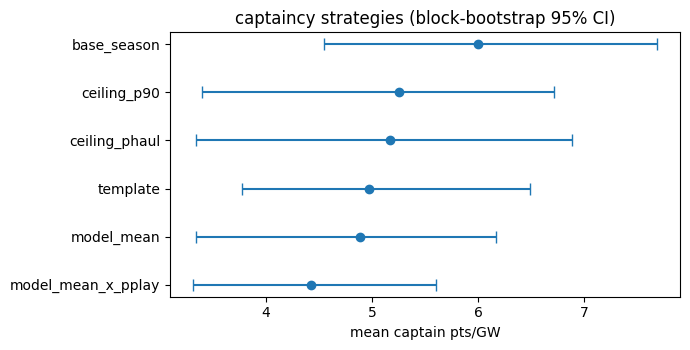

,mean_pts_gw,ci_lo,ci_hi,winrate_vs_template,regret
strategy,,,,,
template,4.971,3.771,6.486,0.000,11.686
base_season,6.000,4.543,7.686,0.114,10.657
model_mean,4.886,3.343,6.171,0.371,11.771
model_mean_x_pplay,4.429,3.314,5.600,0.343,12.229
ceiling_p90,5.257,3.400,6.714,0.371,11.400
ceiling_phaul,5.171,3.343,6.886,0.371,11.486


In [2]:
t=tbl.sort_values('mean_pts_gw')
fig,ax=plt.subplots(figsize=(7,3.6))
ax.errorbar(t['mean_pts_gw'],range(len(t)),
            xerr=[t['mean_pts_gw']-t['ci_lo'],t['ci_hi']-t['mean_pts_gw']],fmt='o',capsize=4,color='#1f77b4')
ax.set_yticks(range(len(t))); ax.set_yticklabels(t.index)
ax.set_xlabel('mean captain pts/GW'); ax.set_title('captaincy strategies (block-bootstrap 95% CI)')
plt.tight_layout(); plt.show()
display(tbl.round(3))

## (b) Win-rate vs template and regret vs the oracle

Win-rate = how often a strategy's captain outscored template's (intuitive, robust to one haul).
Regret = points left on the table vs the perfect pick each GW.

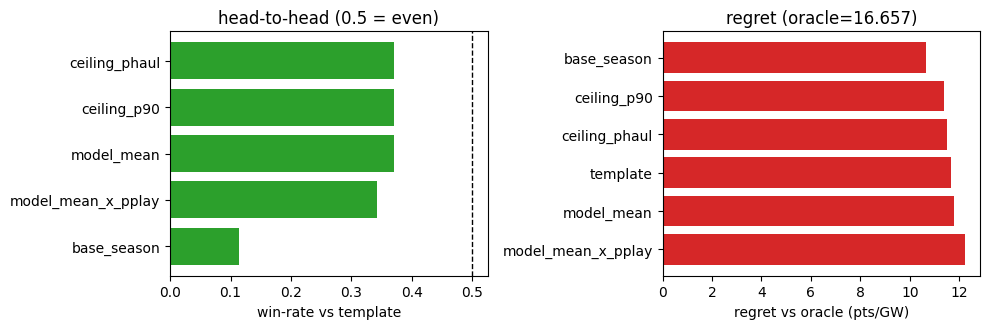

In [3]:
fig,(ax1,ax2)=plt.subplots(1,2,figsize=(10,3.4))
w=tbl.drop('template')['winrate_vs_template'].sort_values()
ax1.barh(w.index,w.values,color='#2ca02c'); ax1.axvline(0.5,color='k',ls='--',lw=1)
ax1.set_xlabel('win-rate vs template'); ax1.set_title('head-to-head (0.5 = even)')
r=tbl['regret'].sort_values(ascending=False)
ax2.barh(r.index,r.values,color='#d62728'); ax2.set_xlabel('regret vs oracle (pts/GW)')
ax2.set_title(f"regret (oracle={tbl.attrs['oracle_mean']})")
plt.tight_layout(); plt.show()

## Summary — Phase 5 verdict (humbling, honest)

**Proven:** a simple **season-average is the best captaincy strategy** in both pool views — the full
model does NOT beat it. **Ceiling > mean** (the distribution adds value) but not enough; the P(play)
multiplier hurt. **On one season, every block-bootstrap CI overlaps — nothing is statistically
separable** (A5.1 vindicated -> multi-season required). Regret ~11 of the oracle's ~17: captaincy is
haul-dominated.

**The point of decision evaluation:** it separates *accurate & calibrated* (proven, Phases 3-4) from
*useful for the decision* (not demonstrable on one season). Next levers: multi-season backtest,
injury-aware `P(play)` (no news here), squad/transfers + team-stacking.